# Part 2 Task 1

In [1]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Configurations

In [2]:
device = "cuda"

batch_size = 128

noise_dim = 64

#optimizer params

lr = 0.0002
beta_1 = 0.5
beta_2 = 0.99

#Training variables

epochs = 20

# Load MNIST Dataset

In [3]:
from torchvision import datasets, transforms as T

In [4]:
train_augs = T.Compose([
    T.RandomRotation((-20,+20)),
    T.ToTensor()
])

In [5]:
trainset =  datasets.MNIST('MNIST/', download=True, train=True, transform=train_augs)

# Load Dataset Into Batches

In [6]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

In [7]:
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [8]:
len(trainloader)

469

In [9]:
dataiter = iter(trainloader)
images, _ = next(dataiter)
print(images.shape)

torch.Size([128, 1, 28, 28])


In [ ]:
def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

# Discriminator

In [12]:
#In case if torch summary is not installed

!pip install torchsummary

In [13]:
from torch import nn
from torchsummary import summary

In [31]:
def get_disc_block(in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.BatchNorm2d(out_channels),
        nn.LeakyReLU(0.2)
    )

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        # First layer for discriminator
        self.block1 = get_disc_block(1, 16, kernel_size=4, stride=2, padding=0)

        self.block2 = get_disc_block(16, 32, kernel_size=4, stride=2, padding=1)
        self.block3 = get_disc_block(32, 64, kernel_size=4, stride=2, padding=1)
        self.block4 = get_disc_block(64, 64, kernel_size=3, stride=1, padding=0)

        # Flatten and linear layer to output discriminator score
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=64, out_features=1)

    def forward(self, images):
        x = self.block1(images)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [32]:
D = Discriminator()
D.to(device)

summary(D, input_size=(1, 28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 13, 13]             272
       BatchNorm2d-2           [-1, 16, 13, 13]              32
         LeakyReLU-3           [-1, 16, 13, 13]               0
            Conv2d-4             [-1, 32, 6, 6]           8,224
       BatchNorm2d-5             [-1, 32, 6, 6]              64
         LeakyReLU-6             [-1, 32, 6, 6]               0
            Conv2d-7             [-1, 64, 3, 3]          32,832
       BatchNorm2d-8             [-1, 64, 3, 3]             128
         LeakyReLU-9             [-1, 64, 3, 3]               0
           Conv2d-10             [-1, 64, 1, 1]          36,928
      BatchNorm2d-11             [-1, 64, 1, 1]             128
        LeakyReLU-12             [-1, 64, 1, 1]               0
          Flatten-13                   [-1, 64]               0
           Linear-14                   

# Generator

In [33]:
def get_gen_block(in_channels, out_channels, kernel_size, stride, padding, final_block=False):
    layers = []
    layers.append(nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding))
    if final_block:
        layers.append(nn.Tanh())
    else:
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(True))
    return nn.Sequential(*layers)

class Generator(nn.Module):
    def __init__(self, noise_dim=64):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim

        # First layer for generator
        self.block1 = get_gen_block(64, 512, kernel_size=4, stride=1, padding=0)

        self.block2 = get_gen_block(512, 256, kernel_size=4, stride=2, padding=1)
        self.block3 = get_gen_block(256, 128, kernel_size=4, stride=2, padding=2)
        self.block4 = get_gen_block(128, 64, kernel_size=4, stride=2, padding=1)
        # Final layer to produce 28x28 grayscale image
        self.block5 = get_gen_block(64, 1, kernel_size=3, stride=1, padding=1, final_block=True)

    def forward(self, noise):
        # Reshape noise vector: (batch_size, noise_dim) -> (batch_size, noise_dim, 1, 1)
        x = noise.view(-1, self.noise_dim, 1, 1)
        x = self.block1(x)  # Output: (batch_size, 512, 4, 4)
        x = self.block2(x)  # Output: (batch_size, 256, 8, 8)
        x = self.block3(x)  # Output: (batch_size, 128, 14, 14)
        x = self.block4(x)  # Output: (batch_size, 64, 28, 28)
        x = self.block5(x)  # Output: (batch_size, 1, 28, 28)
        return x

In [34]:
G = Generator(noise_dim)
G.to(device)
summary(G, input_size=(1,noise_dim))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         524,800
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
              ReLU-3            [-1, 512, 4, 4]               0
   ConvTranspose2d-4            [-1, 256, 8, 8]       2,097,408
       BatchNorm2d-5            [-1, 256, 8, 8]             512
              ReLU-6            [-1, 256, 8, 8]               0
   ConvTranspose2d-7          [-1, 128, 14, 14]         524,416
       BatchNorm2d-8          [-1, 128, 14, 14]             256
              ReLU-9          [-1, 128, 14, 14]               0
  ConvTranspose2d-10           [-1, 64, 28, 28]         131,136
      BatchNorm2d-11           [-1, 64, 28, 28]             128
             ReLU-12           [-1, 64, 28, 28]               0
  ConvTranspose2d-13            [-1, 1, 28, 28]             577
             Tanh-14            [-1, 1,

In [35]:
# Replace Random initialized weights to Normal weights

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [36]:
D = D.apply(weights_init)
G = G.apply(weights_init)

# Create Loss Function and Load Optimizer

In [37]:
def real_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

def fake_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

In [38]:
D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta_1, beta_2))
G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta_1, beta_2))

# Training Loop

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 1 | D_loss: 0.6907 | G_loss: 0.6952


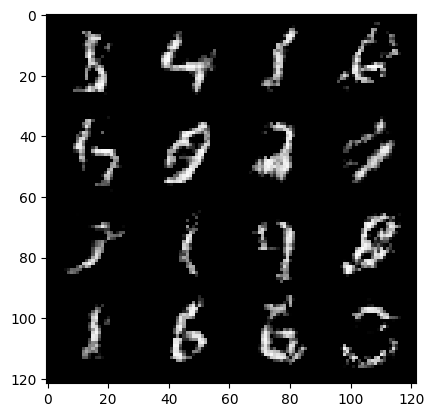

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 2 | D_loss: 0.6814 | G_loss: 0.7096


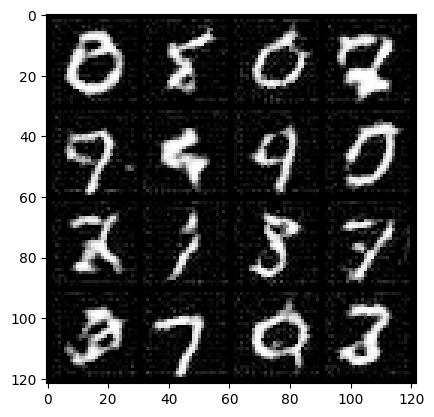

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 3 | D_loss: 0.6708 | G_loss: 0.7234


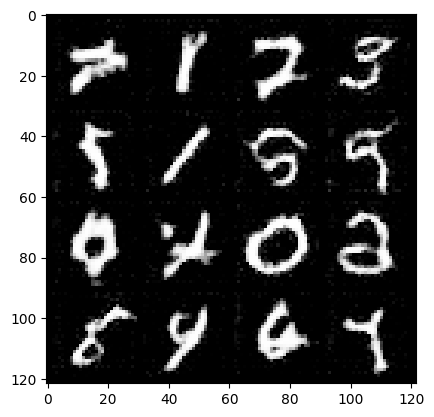

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 4 | D_loss: 0.6679 | G_loss: 0.7320


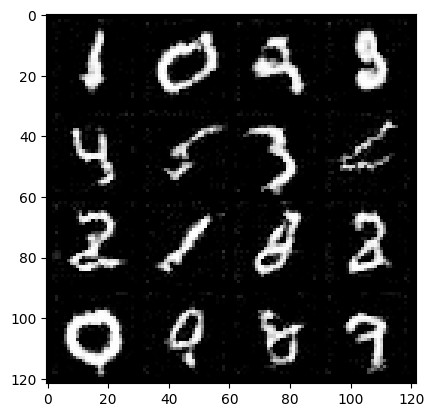

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 5 | D_loss: 0.6693 | G_loss: 0.7342


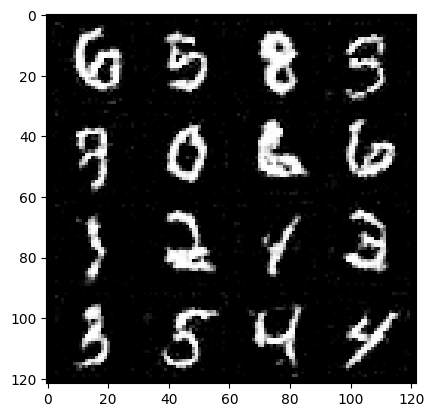

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 6 | D_loss: 0.6725 | G_loss: 0.7328


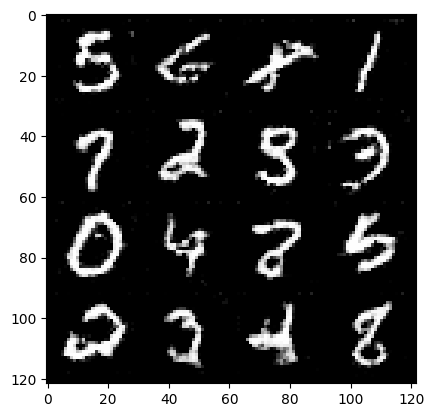

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 7 | D_loss: 0.6767 | G_loss: 0.7284


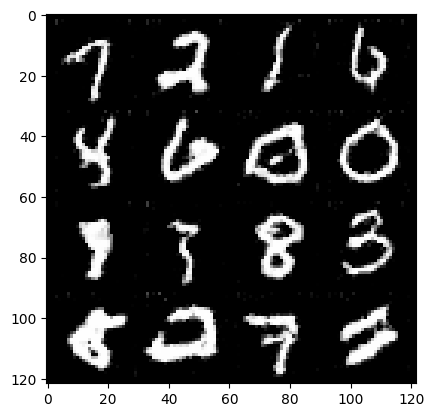

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 8 | D_loss: 0.6810 | G_loss: 0.7259


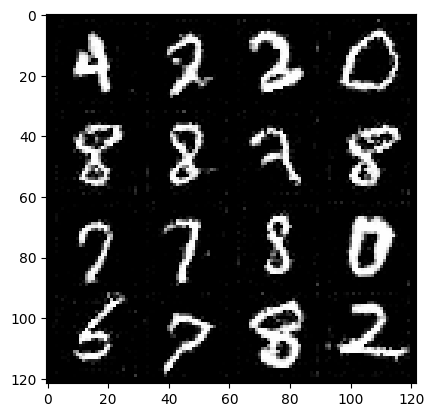

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 9 | D_loss: 0.6830 | G_loss: 0.7220


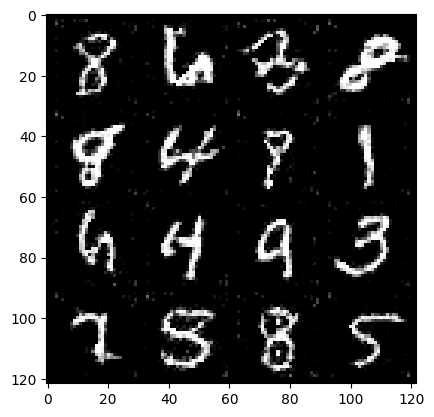

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 10 | D_loss: 0.6855 | G_loss: 0.7181


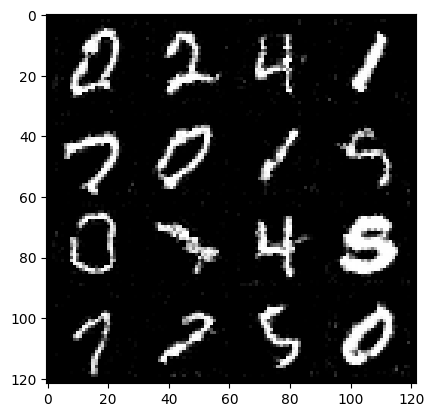

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 11 | D_loss: 0.6856 | G_loss: 0.7173


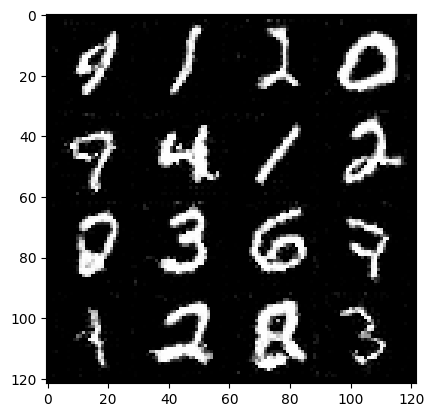

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 12 | D_loss: 0.6869 | G_loss: 0.7150


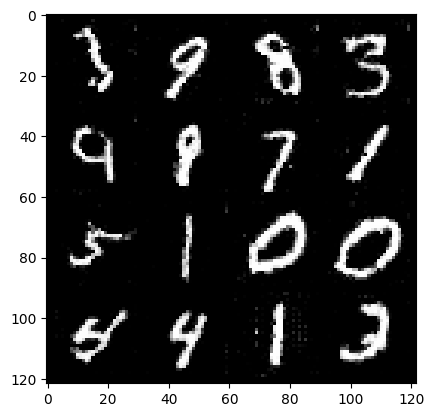

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 13 | D_loss: 0.6880 | G_loss: 0.7129


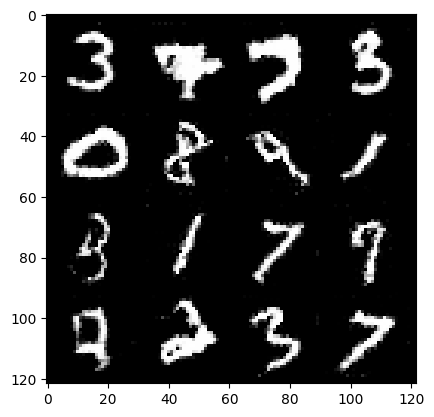

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 14 | D_loss: 0.6887 | G_loss: 0.7111


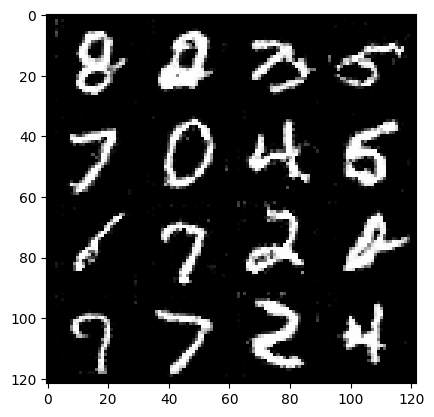

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 15 | D_loss: 0.6891 | G_loss: 0.7100


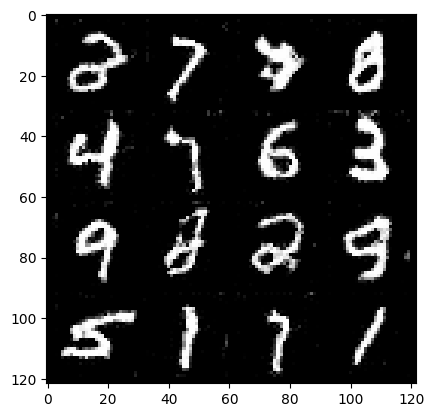

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 16 | D_loss: 0.6898 | G_loss: 0.7078


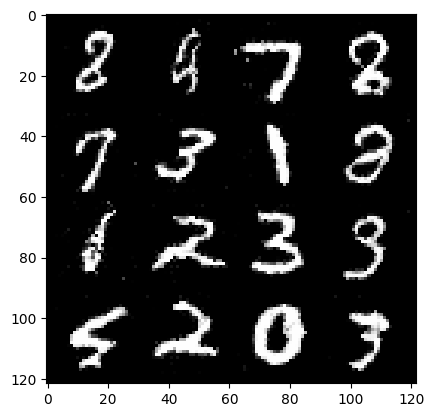

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 17 | D_loss: 0.6906 | G_loss: 0.7078


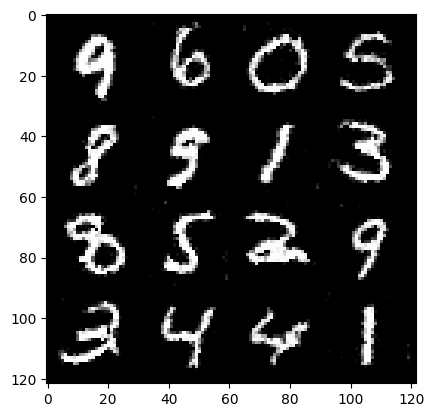

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 18 | D_loss: 0.6906 | G_loss: 0.7069


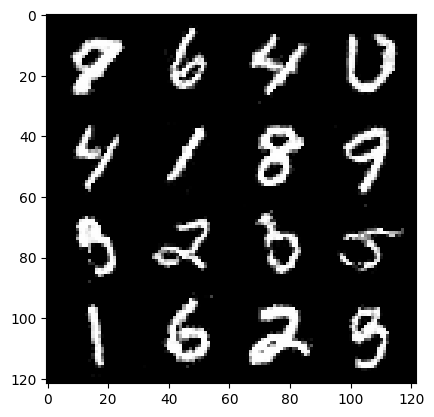

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 19 | D_loss: 0.6908 | G_loss: 0.7050


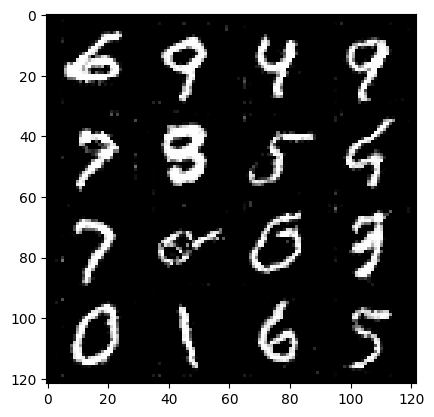

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 20 | D_loss: 0.6916 | G_loss: 0.7043


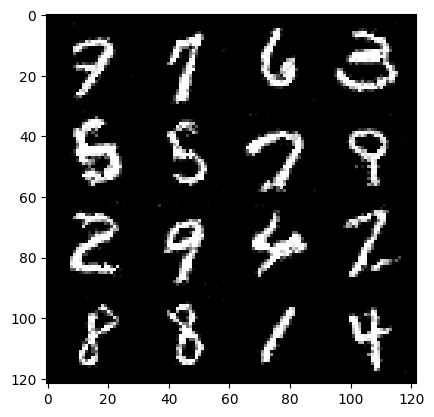

In [39]:
for i in range(epochs):
  total_d_loss = 0.0
  total_g_loss = 0.0

  for real_img, _ in tqdm(trainloader):
    real_img = real_img.to(device)
    noise = torch.randn(batch_size, noise_dim, device=device)

    #find loss and update weights for D

    D_opt.zero_grad()
    fake_img = G(noise)
    D_fake_pred = D(fake_img)
    D_fake_loss = fake_loss(D_fake_pred)

    D_real_pred = D(real_img)
    D_real_loss = real_loss(D_real_pred)

    D_loss = (D_fake_loss + D_real_loss)/2
    total_d_loss += D_loss.item()

    D_loss.backward()
    D_opt.step()

    #find loss and update weights for G
    G_opt.zero_grad()

    noise = torch.randn(batch_size, noise_dim, device=device)

    fake_img = G(noise)
    D_fake_pred = D(fake_img)
    G_loss = real_loss(D_fake_pred)

    total_g_loss += G_loss.item()
    G_loss.backward()
    G_opt.step()

  avg_d_loss = total_d_loss / len(trainloader)
  avg_g_loss = total_g_loss / len(trainloader)

  print(f"Epoch: {i+1} | D_loss: {avg_d_loss:.4f} | G_loss: {avg_g_loss:.4f}")

  show_tensor_images(fake_img)

reference to: https://github.com/saikrishna1312/DCGAN-with-PyTorch/blob/main/Generative_Adversarial_Network_with_PyTorch_.ipynb